In [6]:
import os
import shutil
from PIL import Image
from sahi.slicing import slice_image

In [7]:
def tile_dataset(input_images_dir, input_labels_dir, output_dir, grid=10,
                 overlap_ratio=0.2, min_visibility=0.1):
    """
    Slices each annotated image into a grid x grid set of tiles using SAHI and
    remaps YOLO annotations into each tile's coordinate space. Images without a
    corresponding annotation file are skipped entirely.
    Outputs Ultralytics-compatible structure: output_dir/images/ and output_dir/labels/

    Args:
        input_images_dir (str): Directory containing source images.
        input_labels_dir (str): Directory containing YOLO .txt annotation files.
        output_dir (str): Root output directory.
        grid (int): Number of tiles per side (grid x grid total tiles per image).
        overlap_ratio (float): Fractional overlap between adjacent tiles (e.g. 0.1 = 10%).
        min_visibility (float): Minimum fraction of a box's area that must fall
                                 inside a tile for it to be included (0.0 - 1.0).
    """
    supported = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}

    out_images = os.path.join(output_dir, "images")
    out_labels = os.path.join(output_dir, "labels")
    os.makedirs(out_images, exist_ok=True)
    os.makedirs(out_labels, exist_ok=True)

    classes_src = os.path.join(input_labels_dir, "classes.txt")
    if os.path.exists(classes_src):
        shutil.copy2(classes_src, os.path.join(out_labels, "classes.txt"))

    image_files = [f for f in os.listdir(input_images_dir)
                   if os.path.splitext(f)[1].lower() in supported]

    skipped = 0
    for img_file in image_files:
        stem = os.path.splitext(img_file)[0]
        ext  = os.path.splitext(img_file)[1]
        img_path = os.path.join(input_images_dir, img_file)
        txt_path = os.path.join(input_labels_dir, stem + ".txt")

        # Skip unannotated images entirely
        if not os.path.exists(txt_path):
            skipped += 1
            continue

        img = Image.open(img_path)
        W, H = img.size
        tile_w = int(W / grid)
        tile_h = int(H / grid)

        slice_result = slice_image(
            image=img_path,
            slice_height=tile_h,
            slice_width=tile_w,
            overlap_height_ratio=overlap_ratio,
            overlap_width_ratio=overlap_ratio,
            output_file_name=stem,
            output_dir=out_images,
            verbose=False,
        )

        annotations = []
        with open(txt_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls = int(parts[0])
                    xc, yc, bw, bh = map(float, parts[1:])
                    x1 = (xc - bw / 2) * W
                    y1 = (yc - bh / 2) * H
                    x2 = (xc + bw / 2) * W
                    y2 = (yc + bh / 2) * H
                    annotations.append((cls, x1, y1, x2, y2))

        for sliced_img in slice_result.sliced_image_list:
            tx1 = sliced_img.starting_pixel[0]
            ty1 = sliced_img.starting_pixel[1]

            th, tw = sliced_img.image.shape[:2]
            tx2, ty2 = tx1 + tw, ty1 + th

            tile_anns = []
            for cls, x1, y1, x2, y2 in annotations:
                cx1 = max(x1, tx1)
                cy1 = max(y1, ty1)
                cx2 = min(x2, tx2)
                cy2 = min(y2, ty2)

                if cx2 <= cx1 or cy2 <= cy1:
                    continue

                orig_area    = (x2 - x1) * (y2 - y1)
                clipped_area = (cx2 - cx1) * (cy2 - cy1)
                if orig_area > 0 and clipped_area / orig_area < min_visibility:
                    continue

                new_xc = ((cx1 + cx2) / 2 - tx1) / tw
                new_yc = ((cy1 + cy2) / 2 - ty1) / th
                new_bw = (cx2 - cx1) / tw
                new_bh = (cy2 - cy1) / th
                tile_anns.append(f"{cls} {new_xc:.6f} {new_yc:.6f} {new_bw:.6f} {new_bh:.6f}")

            tile_filename = sliced_img.coco_image.file_name
            tile_stem = os.path.splitext(os.path.basename(tile_filename))[0]
            with open(os.path.join(out_labels, tile_stem + ".txt"), "w") as f:
                f.write("\n".join(tile_anns) + ("\n" if tile_anns else ""))

        print(f"Tiled: {img_file} -> {len(slice_result.sliced_image_list)} tiles")

    if skipped:
        print(f"Skipped {skipped} unannotated images.")
    print("Done.")

In [8]:
GRID           = 2
OVERLAP_RATIO  = 0.2
MIN_VISIBILITY = 0.1
OUTPUT_PATH    = "data/tiled_3200_v3"
FOLDER = 'split_AI'

# Wipe and rebuild tiled output from scratch each run
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)
    print(f"Cleared {OUTPUT_PATH}/")

for split in ["train", "val", "test"]:
    tile_dataset(
        input_images_dir=f"data/{FOLDER}/{split}/images",
        input_labels_dir=f"data/{FOLDER}/{split}/labels",
        output_dir=f"{OUTPUT_PATH}/{split}",
        grid=GRID,
        overlap_ratio=OVERLAP_RATIO,
        min_visibility=MIN_VISIBILITY,
    )

# Save tiling settings for reference
settings_path = f"{OUTPUT_PATH}/tiling_settings.txt"
with open(settings_path, "w") as f:
    f.write(f"grid:           {GRID}x{GRID}\n")
    f.write(f"overlap_ratio:  {OVERLAP_RATIO}\n")
    f.write(f"min_visibility: {MIN_VISIBILITY}\n")
print(f"Settings saved to {settings_path}")
print("All splits tiled.")

Tiled: 2025.04.23_S1-01-PBXT0_500 PBMCs per well_plated 04.02.25_3wk_B1.jpg -> 9 tiles
Tiled: 2025.04.23_S1-01-PBXT0_500 cd34+ per well_plated 04.02.25_3wk_A2.jpg -> 9 tiles
Tiled: 2025.04.23_S1-01-PBXT0_500 cd34+ per well_plated 04.02.25_3wk_A1.jpg -> 9 tiles
Tiled: 05.28.25_S1-03-PB0_500 CD34+s per well_plated 05.14.25_2wks-retake_A1.jpg -> 9 tiles
Tiled: 06.17.25_BHEEM-04-Cycle1-Day1_500 CD34+s_plated 05.27.25_A1.jpg -> 9 tiles
Tiled: 2025.07.22_S1-01-mPB1-D1-fk_500 CD34+s_plated 07.08.25_2wks_B2.jpg -> 9 tiles
Tiled: 05.01.25_S1-02-PB0_100k PBMCs per well_plated 04.15.25_16 days_#3 for condensation_A3.jpg -> 9 tiles
Tiled: 06.04.25_S1-03-BM0_500 CD34+s per well_plated 05.14.25_3wks_B3.jpg -> 9 tiles
Tiled: 03.24.26_S1-05-PB0_100k PBMCs per well_plated 03.10.26_2wks#2_A3.jpg -> 9 tiles
Tiled: 03.24.26_S1-05-PB0_100k PBMCs per well_plated 03.10.26_2wks#2_A2.jpg -> 9 tiles
Tiled: 2025.07.22_S1-01-mPB1-D2-fk_500 CD34+s_plated 07.09.25_2wks_A3.jpg -> 9 tiles
Tiled: 06.10.25_BHEEM-04-Cyc

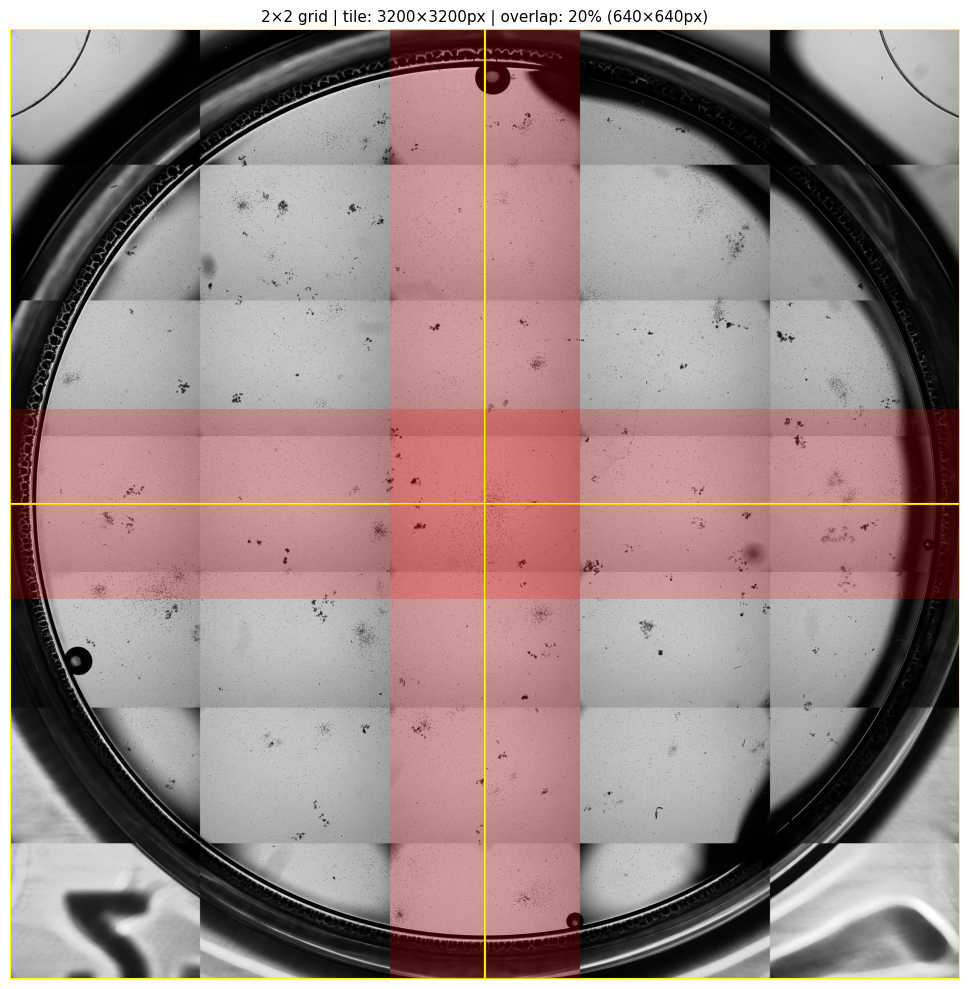

Total tiles: 4 | Image: 6400×6400px


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_tiling(image_path, grid=5, overlap_ratio=0.1):
    """
    Draws the tile grid and overlap strips on a sample image so you can
    verify slicing parameters before running the full pipeline.
    """
    img = Image.open(image_path)
    W, H = img.size
    tile_w = W // grid
    tile_h = H // grid
    overlap_w = int(tile_w * overlap_ratio)
    overlap_h = int(tile_h * overlap_ratio)

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(img)

    for row in range(grid):
        for col in range(grid):
            x = col * tile_w
            y = row * tile_h

            # Core tile border
            ax.add_patch(patches.Rectangle(
                (x, y), tile_w, tile_h,
                linewidth=1.5, edgecolor='yellow', facecolor='none'
            ))

            # Overlap strips on both sides of every boundary
            if col > 0:        # left overlap (leading edge)
                ax.add_patch(patches.Rectangle(
                    (x, y), overlap_w, tile_h,
                    linewidth=0, facecolor='red', alpha=0.2
                ))
            if col < grid - 1: # right overlap (trailing edge)
                ax.add_patch(patches.Rectangle(
                    (x + tile_w - overlap_w, y), overlap_w, tile_h,
                    linewidth=0, facecolor='red', alpha=0.2
                ))
            if row > 0:        # top overlap (leading edge)
                ax.add_patch(patches.Rectangle(
                    (x, y), tile_w, overlap_h,
                    linewidth=0, facecolor='red', alpha=0.2
                ))
            if row < grid - 1: # bottom overlap (trailing edge)
                ax.add_patch(patches.Rectangle(
                    (x, y + tile_h - overlap_h), tile_w, overlap_h,
                    linewidth=0, facecolor='red', alpha=0.2
                ))

    ax.set_title(
        f"{grid}×{grid} grid | tile: {tile_w}×{tile_h}px | "
        f"overlap: {overlap_ratio*100:.0f}% ({overlap_w}×{overlap_h}px)",
        fontsize=11
    )
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    print(f"Total tiles: {grid*grid} | Image: {W}×{H}px")


# --- Edit these to match your intended training parameters ---
SAMPLE_IMAGE    = "data/split/train/images/03.24.26_S1-05-PB0_100k PBMCs per well_plated 03.10.26_2wks#2_A2.jpg"
PREVIEW_GRID    = 2
PREVIEW_OVERLAP = 0.2

visualize_tiling(SAMPLE_IMAGE, grid=PREVIEW_GRID, overlap_ratio=PREVIEW_OVERLAP)